In [1]:
#read all csv
import os
import pandas as pd

# Define the path to the data directory
data_dir = "data/raw/csv/ttc_subway_delay"

# List all CSV files in the data directory
csv_files = [f for f in os.listdir(data_dir) if f.endswith(".csv")]

# Read each CSV file into a DataFrame and store in a list
dfs = []
for file in csv_files:
    df = pd.read_csv(os.path.join(data_dir, file))
    dfs.append(df)
    print(f"Loaded {file}")

# Concatenate all DataFrames into a single DataFrame
combined_df = pd.concat(dfs, ignore_index=True)
print("All CSV files have been combined into a single DataFrame.")

#drop id column
if 'id' in combined_df.columns:
    combined_df = combined_df.drop(columns=['id'])
    print("Dropped 'id' column from the combined DataFrame.")

# Display the first few rows of the combined DataFrame
print(combined_df.head())

#write in data/processed/combined_data.csv# Define the path to the output file
output_file = "data/processed/ttc_subway_delay_data_combined.csv"
# Save the combined DataFrame to a new CSV file
combined_df.to_csv(output_file, index=False)
print(f"Combined data has been saved to {output_file}.")

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data/raw/csv/ttc_subway_delay'

In [ ]:
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250558 entries, 0 to 250557
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   Date       250558 non-null  str  
 1   Time       250558 non-null  str  
 2   Day        250558 non-null  str  
 3   Station    250558 non-null  str  
 4   Code       250557 non-null  str  
 5   Min Delay  250558 non-null  int64
 6   Min Gap    250558 non-null  int64
 7   Bound      182186 non-null  str  
 8   Line       249784 non-null  str  
 9   Vehicle    250558 non-null  int64
dtypes: int64(3), str(7)
memory usage: 19.1 MB


In [ ]:
combined_df.describe()

,Min Delay,Min Gap,Vehicle
count,250558.000000,250558.000000,250558.000000
mean,2.573476,3.765268,3656.604303
std,10.147155,10.333965,2589.034616
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,5180.000000
75%,3.000000,7.000000,5601.000000
max,999.000000,999.000000,72537.000000


In [ ]:
#null % and count in each column
null_percentage = combined_df.isnull().mean() * 100
null_count = combined_df.isnull().sum()
print("Percentage of null values in each column:")
print(null_percentage)
print("\nCount of null values in each column:")
print(null_count)

Percentage of null values in each column:
Date          0.000000
Time          0.000000
Day           0.000000
Station       0.000000
Code          0.000399
Min Delay     0.000000
Min Gap       0.000000
Bound        27.287893
Line          0.308911
Vehicle       0.000000
dtype: float64

Count of null values in each column:
Date             0
Time             0
Day              0
Station          0
Code             1
Min Delay        0
Min Gap          0
Bound        68372
Line           774
Vehicle          0
dtype: int64


In [ ]:
# change the data type of date column to datetime
combined_df['Date'] = pd.to_datetime(combined_df['Date'], errors='coerce')
# add year, month columns
combined_df['Year'] = combined_df['Date'].dt.year
combined_df['Month'] = combined_df['Date'].dt.month


In [ ]:
#null % and count in each column by year
null_percentage = combined_df.groupby('Year').apply(lambda x: x.isnull().mean() * 100)
null_count = combined_df.groupby('Year').apply(lambda x: x.isnull().sum())
print("Percentage of null values in each column by year:")
print(null_percentage)
print("\nCount of null values in each column by year:")
print(null_count)

Percentage of null values in each column by year:
      Date  Time  Day  Station      Code  Min Delay  Min Gap      Bound  \
Year                                                                      
2014   0.0   0.0  0.0      0.0  0.000000        0.0      0.0  22.370740   
2015   0.0   0.0  0.0      0.0  0.000000        0.0      0.0  21.146503   
2016   0.0   0.0  0.0      0.0  0.000000        0.0      0.0  20.659673   
2017   0.0   0.0  0.0      0.0  0.005295        0.0      0.0  21.445592   
2018   0.0   0.0  0.0      0.0  0.000000        0.0      0.0  22.664802   
2019   0.0   0.0  0.0      0.0  0.000000        0.0      0.0  22.786391   
2020   0.0   0.0  0.0      0.0  0.000000        0.0      0.0  24.942498   
2021   0.0   0.0  0.0      0.0  0.000000        0.0      0.0  25.968235   
2022   0.0   0.0  0.0      0.0  0.000000        0.0      0.0  27.876351   
2023   0.0   0.0  0.0      0.0  0.000000        0.0      0.0  37.151946   
2024   0.0   0.0  0.0      0.0  0.000000        0.

- Bound column is consistently null for ~20% of data

In [ ]:
station_counts = combined_df['Station'].value_counts()   
print(station_counts)

Station
KENNEDY BD STATION        9893
FINCH STATION             9467
KIPLING STATION           9436
BLOOR STATION             7306
EGLINTON STATION          6628
                          ... 
LEAVING YONGE-SHEPPARD       1
DAVENPORT BUILDING           1
CLANTON PARK EMERGENCY       1
PRINCE EDWARD VIADUCT        1
MOORE GATE                   1
Name: count, Length: 1609, dtype: int64


In [ ]:
# find null values in columns
null_values = combined_df.isnull().sum()
print("Null values in each column:")
print(null_values)

Null values in each column:
Date             0
Time             0
Day              0
Station          0
Code             1
Min Delay        0
Min Gap          0
Bound        68372
Line           774
Vehicle          0
Year             0
Month            0
dtype: int64


In [ ]:
#find the number of unique values in each column
unique_values = combined_df.nunique()
print("Number of unique values in each column:")
print(unique_values)    

Number of unique values in each column:
id           28191
Date          4414
Time          1440
Day              7
Station       1609
Code           225
Min Delay      255
Min Gap        250
Bound            9
Line            99
Vehicle       1556
Year            13
Month           12
dtype: int64


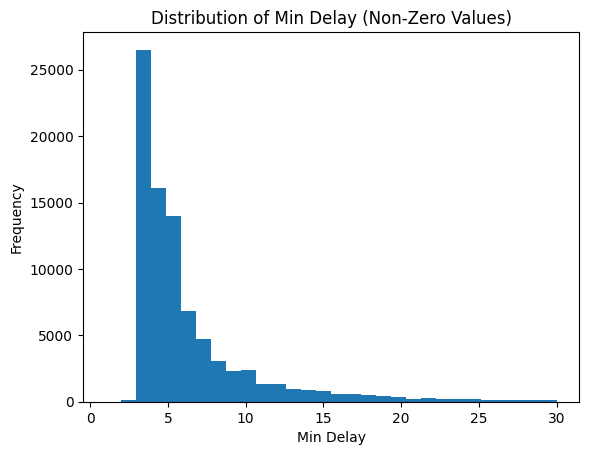

In [ ]:
# plot the distribution of the target variable (Min Delay) where column is non zero and range is between 1 and 30
import matplotlib.pyplot as plt 
plt.hist(combined_df[(combined_df['Min Delay'] > 0) & (combined_df['Min Delay'] <= 30)]['Min Delay'], bins=30)
plt.xlabel('Min Delay')
plt.ylabel('Frequency')
plt.title('Distribution of Min Delay (Non-Zero Values)')
plt.show()

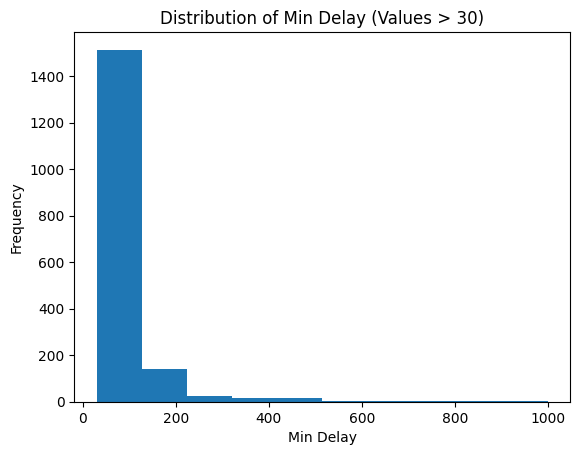

In [ ]:
# plot the distribution of the target variable (Min Delay) where column is non zero and greater than 30
import matplotlib.pyplot as plt 
plt.hist(combined_df[combined_df['Min Delay'] > 30]['Min Delay'], bins=10)
plt.xlabel('Min Delay')
plt.ylabel('Frequency')
plt.title('Distribution of Min Delay (Values > 30)')
plt.show()

In [ ]:
# find outliers % in the target variable (Min Delay) where column is non zero and greater than 200
outliers = combined_df[combined_df['Min Delay'] > 30]
outliers_percentage = len(outliers) / len(combined_df) * 100
print(f"Percentage of outliers (Min Delay > 30): {outliers_percentage:.2f}%")

Percentage of outliers (Min Delay > 30): 0.69%


In [ ]:
# read master data
master_df = pd.read_csv("data/master/ttc_subway_station_master.csv")
print(master_df.head()) 

             Station     Location        Grade
0              Finch   North York  Underground
1  North York Centre   North York  Underground
2     Sheppard–Yonge   North York  Underground
3         York Mills   North York  Underground
4           Lawrence  Old Toronto  Underground


In [ ]:
import pandas as pd
from thefuzz import process

#replace the station string in combined_df with blank
combined_df["Station_clean"] = combined_df["Station"].str.replace(" STATION", "")
combined_df["Station_clean"] = combined_df["Station_clean"].str.replace(" STATIO", "")
df1 = combined_df.groupby(["Station", "Station_clean"]).size().reset_index(name="count")
df2 = master_df

def fuzzy_match(val, choices, threshold=80):
    result = process.extractOne(val, choices)
    if result:
        match, score = result
        return pd.Series([match, score])
    return pd.Series([None, 0])

df1[["matched_name", "score"]] = df1["Station_clean"].apply(
    lambda x: fuzzy_match(x, df2["Station"].tolist())
)

print(df1[["Station", "matched_name", "score"]])

                     Station     matched_name  score
0              (APPROACHING)             King     77
1      (APPROACHING) KENNEDY          Kennedy     90
2     1 ST CLAIR AVENUE EAST           Avenue     90
3             1 TIPPETT ROAD             Pape     68
4           111 SPADINA ROAD          Spadina     90
...                      ...              ...    ...
1604   YUS/BD/SEPPARD SUBWAY              Bay     72
1605  YUS/BD/SHEPPARD SUBWAY   Sheppard–Yonge     86
1606              YUS/BD/SRT      Dundas West     48
1607                  ZONE 1  Pioneer Village     60
1608                  ZONE 2  Pioneer Village     60

[1609 rows x 3 columns]


In [ ]:
df1.to_csv("data/processed/combined_with_master.csv", index=False)

In [ ]:
import pandas as pd
from thefuzz import process


#replace the code string in combined_df with blank
df1 = combined_df.groupby(["Code"]).size().reset_index(name="count")
df2 = pd.read_csv("data/raw/Code Descriptions.csv")

def fuzzy_match(val, choices, threshold=80):
    result = process.extractOne(val, choices)
    if result:
        match, score = result
        return pd.Series([match, score])
    return pd.Series([None, 0])

df1[["matched_name", "score"]] = df1["Code"].apply(
    lambda x: fuzzy_match(x, df2["CODE"].tolist())
)

print(df1)

      Code  count matched_name  score
0     ERAC     43         EUAC     75
1     ERBO     21         EUBO     75
2     ERCD     92         EUCD     75
3     ERCO     42         EUCO     75
4     ERDB     73        EUTRD     67
..     ...    ...          ...    ...
220   TUST    279         TUST    100
221  TUSUP    370        TUSUP    100
222   TUTD      1         MUTD     75
223   TUUR      3         TUUR    100
224  XXXXX     14         EUAC      0

[225 rows x 4 columns]


In [ ]:
print(df2.shape)
print(df2)

(140, 3)
      id   CODE                              DESCRIPTION
0      1   EUAC                         AIR CONDITIONING
1      2   EUAL                      ALTERNATING CURRENT
2      3  EUATC                       ATC RC&S EQUIPMENT
3      4   EUBK                                   BRAKES
4      5   EUBO                                     BODY
..   ...    ...                                      ...
135  136   TUSC                       OPERATOR OVERSPEED
136  137  TUSET           CONTROLS IMPROPERLY BLOWN DOWN
137  138   TUST                             STORM TRAINS
138  139  TUSUP                        SUPERVISORY ERROR
139  140   TUUR  UNAUTHORIZED TRAIN REVERSAL BY OPERATOR

[140 rows x 3 columns]


In [ ]:
df1.to_csv("data/processed/code_analysis.csv", index=False)

In [ ]:
# read data from ttc_subway_delay_data_combined.csv into data frame and display the first few rows
import pandas as pd

# Define the path to the input file
input_file = "data/processed/ttc_subway_delay_data_combined.csv"

# Read the CSV file into a DataFrame
df = pd.read_csv(input_file)

# Display the first few rows of the DataFrame
print(df.head())


         Date   Time       Day                Station  Code  Min Delay  \
0  2026-01-01  02:09  Thursday       SHEPPARD STATION  SUAP          0   
1  2026-01-01  02:28  Thursday        KIPLING STATION  MUIS          0   
2  2026-01-01  03:19  Thursday  SHEPPARD WEST STATION  MUIS          0   
3  2026-01-01  03:44  Thursday            VMC STATION  MUIS          0   
4  2026-01-01  03:53  Thursday        KIPLING STATION  MUIS          0   

   Min Gap Bound Line  Vehicle  
0        0   NaN   YU        0  
1        0     E   BD     5179  
2        0   NaN   YU        0  
3        0   NaN   YU        0  
4        0   NaN   BD        0  


In [ ]:
#found duplicate rows in the data frame and add count of duplicate rows with row itself
duplicate_rows = df[df.duplicated(keep=False)]
print("Duplicate rows in the DataFrame:")
print(duplicate_rows)
print("Count of duplicate rows:", len(duplicate_rows))

Duplicate rows in the DataFrame:
              Date   Time        Day                 Station   Code  \
64      2026-01-01  00:40   Thursday          WILSON STATION  PUOPO   
66      2026-01-01  00:40   Thursday          WILSON STATION  PUOPO   
883     2026-01-14  06:00  Wednesday  TORONTO TRANSIT COMMIS    MUO   
884     2026-01-14  06:00  Wednesday  TORONTO TRANSIT COMMIS    MUO   
980     2026-01-15  06:11   Thursday        EGLINTON STATION  PUSIS   
...            ...    ...        ...                     ...    ...   
245795  2016-10-13  22:00   Thursday   YONGE UNIVERSITY LINE    MUO   
246425  2016-10-25  06:00    Tuesday  TORONTO TRANSIT COMMIS    MUO   
246426  2016-10-25  06:00    Tuesday  TORONTO TRANSIT COMMIS    MUO   
246427  2016-10-25  06:00    Tuesday  TORONTO TRANSIT COMMIS    MRO   
246428  2016-10-25  06:00    Tuesday  TORONTO TRANSIT COMMIS    MRO   

        Min Delay  Min Gap Bound   Line  Vehicle  
64              0        0     S     YU     5816  
66          

In [ ]:
combined_df.groupby(["Code"]).size().reset_index(name="count")

,Code,count
0,ERAC,43
1,ERBO,21
2,ERCD,92
3,ERCO,42
4,ERDB,73
...,...,...
220,TUST,279
221,TUSUP,370
222,TUTD,1
223,TUUR,3


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

#importing the 2025 csv ttc subway delay data as a pandas dataframe
#df_2025 = pd.read_csv('C:/Users/safab/ML7-Project/C8ML7_subwaydelay/data/raw/csv/ttc-subway-delay-data-2025.csv')
df = pd.read_csv('C:/Users/safab/ML7-Project/C8ML7_subwaydelay/data/processed/ttc_subway_delay_data_obt.csv')

#Adding a new column that is a formatted Year Column into data type Date rather than a string
df['Formatted Date'] = pd.to_datetime(df['date'])

#Extracted Year, Month, and Day from Date
df['Year'] = df['Formatted Date'].dt.year
df['Month'] = df['Formatted Date'].dt.month
df['Day of the Month'] = df['Formatted Date'].dt.day

#Formatted time from string to time and extracting hour of day
df['Formatted Time'] = pd.to_datetime(df['time'], format='%H:%M').dt.time
df['Hour'] = pd.to_datetime(df['time'], format='%H:%M').dt.hour 

#dropped preformatted columns, as well columns that are not used such as id and Bound
columns_to_drop = ['date', 'time', 'bound']

df = df.drop(columns=columns_to_drop)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24389 entries, 0 to 24388
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   day                 24389 non-null  str           
 1   station             24389 non-null  str           
 2   code                24389 non-null  str           
 3   delayed_minutes     24389 non-null  int64         
 4   gap_minutes         24389 non-null  int64         
 5   line                24388 non-null  str           
 6   vehicle             24389 non-null  int64         
 7   year                24389 non-null  int64         
 8   datetime            24389 non-null  str           
 9   hour                24389 non-null  int64         
 10  weekday             24389 non-null  int64         
 11  is_weekend          24389 non-null  int64         
 12  month               24389 non-null  int64         
 13  week                24389 non-null  int64         
 14  p

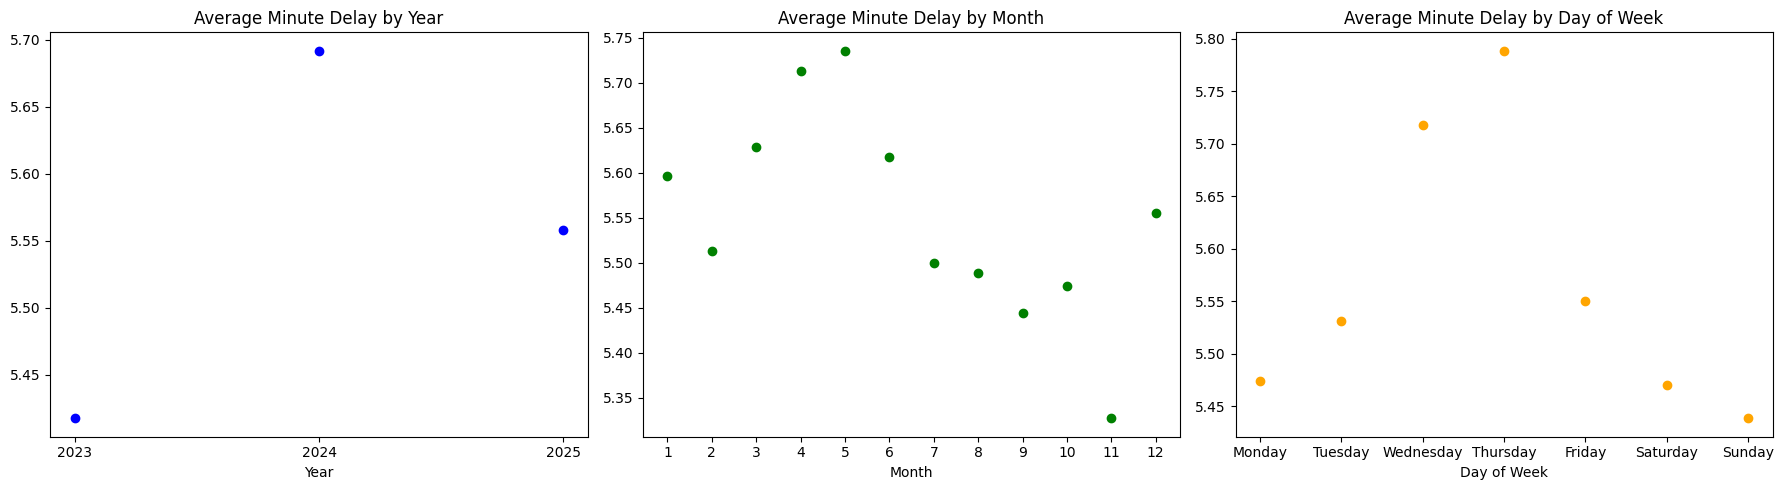

In [3]:
#Combining all three plots of Avg. Minute Delay per Day of week, month, and year in one fig. 

#A list of the y values for the plots (delayed minutes grouped by respective feature)
year_avg_groupby = df.groupby(df['year'])['delayed_minutes'].mean()
monthly_avg_groupby = df.groupby(df['month'])['delayed_minutes'].mean()
dayofweek_avg_groupby = df.groupby(df['day'])['delayed_minutes'].mean()

#Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Average Minute Delay by Year
axes[0].scatter(df['year'].unique(), year_avg_groupby, color='blue')
axes[0].set_xlabel("Year")
axes[0].set_xticks([2023,2024,2025])
axes[0].set_title("Average Minute Delay by Year")

# Average Minute Delay by Month
axes[1].scatter(df['month'].unique(), monthly_avg_groupby, color='green')
axes[1].set_xlabel("Month")
axes[1].set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
axes[1].set_title("Average Minute Delay by Month")

# Average Minute Delay by Day of Week
axes[2].scatter(df['day'].unique(),dayofweek_avg_groupby, color='orange')
axes[2].set_xlabel("Day of Week")
axes[2].set_title("Average Minute Delay by Day of Week")


# Save before showing
plt.tight_layout()
#plt.savefig("avg_minute_day_per_time.png", dpi=300, bbox_inches='tight')  # Save first
plt.show()  # Then show

In [4]:
#This code aims to showcase the top5 stations with the highest tot+

# Filter only rows with actual delays
delays_df = df[df["delayed_minutes"] > 0].copy()
#delays_df = df

# Group by station and calculate delay metrics
station_delay_summary = delays_df.groupby("mapped_station").agg(
    Total_Incidents=("delayed_minutes", "count"),
    Total_Min_Delay=("delayed_minutes", "sum"),
    Avg_Delay_Per_Incident=("delayed_minutes", "mean")
).sort_values(by="Total_Incidents", ascending=False)

#Round average delay
station_delay_summary["Avg_Delay_Per_Incident"] = station_delay_summary["Avg_Delay_Per_Incident"].round(2)

#Display top 5 stations with most delay incidents
station_delay_summary.head(5)

,Total_Incidents,Total_Min_Delay,Avg_Delay_Per_Incident
mapped_station,,,
Sheppard–Yonge,1085,5867,5.41
Eglinton,1082,6078,5.62
Kennedy,994,4770,4.80
Kipling,963,4537,4.71
Finch,858,4072,4.75


Available station names (sample): ['Sheppard–Yonge', 'Eglinton', 'Kennedy', 'Kipling', 'Finch', 'St. George', 'Bloor–Yonge', 'Wilson', 'Dundas West', 'Davisville']


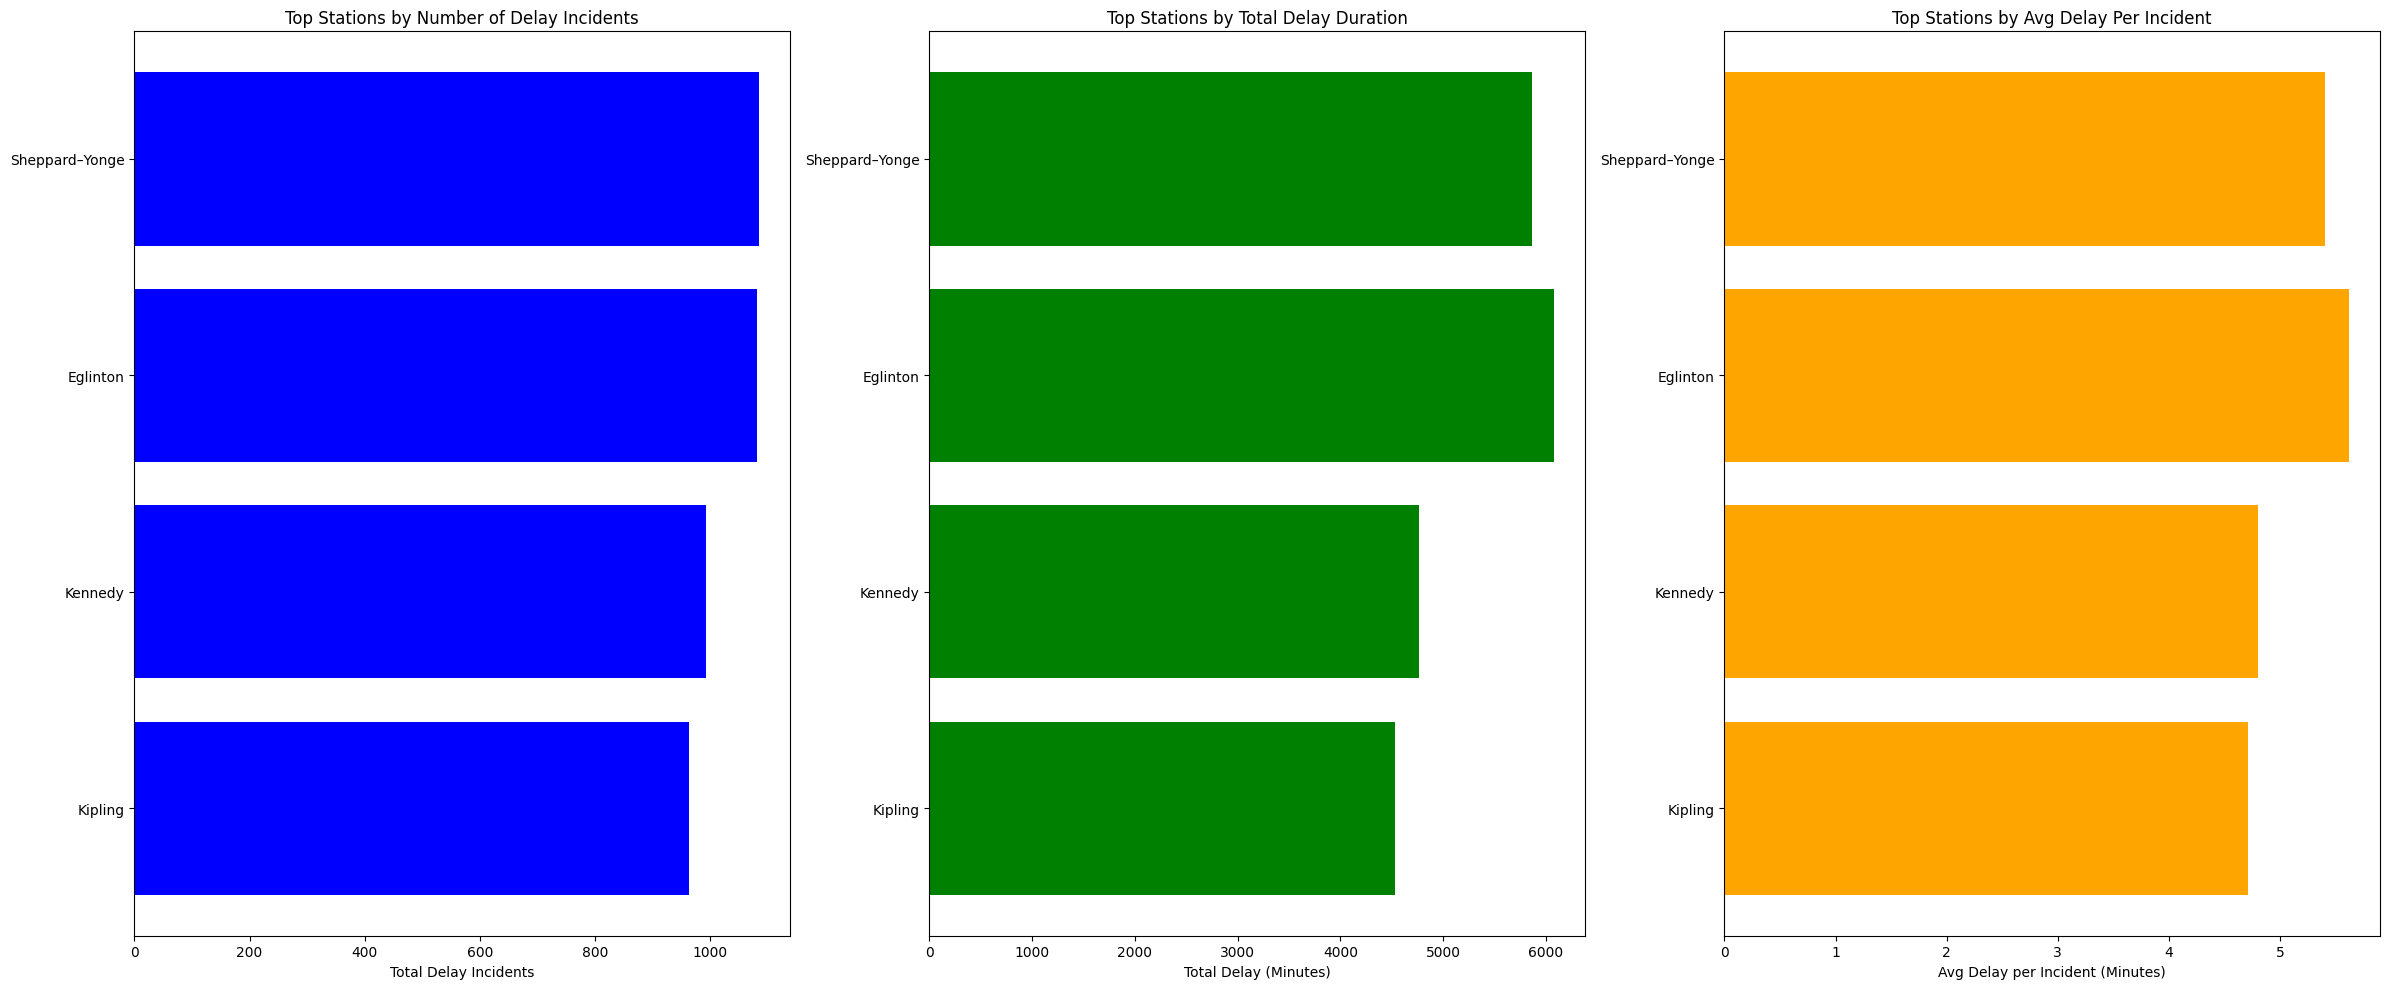

In [5]:
# Step 1: Get top 5 stations by Total_Incidents
top_stations = station_delay_summary.sort_values(by="Total_Incidents", ascending=False).head(4)

print("Available station names (sample):", station_delay_summary.index.tolist()[:10])  # See what's in the index

# Step 4: Plotting
fig, axes = plt.subplots(1, 3, figsize=(24, 10))
stations_reversed = top_stations.index[::-1]

# Total Incidents
axes[0].barh(stations_reversed, top_stations.loc[stations_reversed]["Total_Incidents"], color='blue')
axes[0].set_xlabel("Total Delay Incidents")
axes[0].set_title("Top Stations by Number of Delay Incidents")

# Total Delay
axes[1].barh(stations_reversed, top_stations.loc[stations_reversed]["Total_Min_Delay"], color='green')
axes[1].set_xlabel("Total Delay (Minutes)")
axes[1].set_title("Top Stations by Total Delay Duration")

# Avg Delay
axes[2].barh(stations_reversed, top_stations.loc[stations_reversed]["Avg_Delay_Per_Incident"], color='orange')
axes[2].set_xlabel("Avg Delay per Incident (Minutes)")
axes[2].set_title("Top Stations by Avg Delay Per Incident")


# Save before showing
plt.tight_layout()
plt.savefig("top_stations_with_delays.png", dpi=300, bbox_inches='tight')  # Save first
plt.show()  # Then show